##### Copyright 2022 The Cirq Developers

# Quantum Virtual Machine

In [1]:
import pandas as pd

file_path = '/content/Red_Trafico_Enriquecida_Unificada.xlsx'
df_red_trafico = pd.read_excel(file_path)

print('DataFrame loaded successfully. Here are the first 5 rows:')
display(df_red_trafico.head())

DataFrame loaded successfully. Here are the first 5 rows:


,Unnamed: 0,Unnamed: 1
0,NaN,CONJUNTO DE DATOS ENRIQUECIDO PARA PRUEBAS DE RED
1,NaN,Infraestructura lógica unificada e interconexi...
2,NaN,NaN
3,NaN,MÉTRICAS CLAVE DE NODOS (V)
4,NaN,Total de Nodos Activos:


In [4]:
# Load the 'nodes' data from the second sheet (index 1), with header on the second row (index 1)
df_nodes = pd.read_excel(file_path, sheet_name=1, header=1)

print("DataFrame for Nodes (Sheet 2) reloaded with correct header. Here are the first 5 rows:")
display(df_nodes.head())

DataFrame for Nodes (Sheet 2) reloaded with correct header. Here are the first 5 rows:


,ID Nodo,Tipo de Hardware,Función Operativa,Ubicación/Ámbito,Capacidad (Gbps),Latencia (ms),Criticidad
0,V0_Paracho,Router_Acceso_Regional,Enrutamiento,Red,202.0,6.98,Baja-Media
1,V1_RouterLocal,Router_Acceso_Regional,Enrutamiento,Red,370.0,6.66,Baja-Media
2,V2_Morelia,Router_Core_Troncal,Enrutamiento,Red,4772.0,2.19,Alta
3,V2_Uruapan,Router_Core_Troncal,Enrutamiento,Red,3169.0,1.31,Alta
4,V3_ISP_CDMX,Router_Core_Troncal,Enrutamiento,Red,1330.0,1.92,Alta


In [5]:
# Load the 'edges' data from the third sheet (index 2), with header on the second row (index 1)
df_edges = pd.read_excel(file_path, sheet_name=2, header=1)

print("\nDataFrame for Edges (Sheet 3) reloaded with correct header. Here are the first 5 rows:")
display(df_edges.head())


DataFrame for Edges (Sheet 3) reloaded with correct header. Here are the first 5 rows:


,ID Enlace,Nodo Origen (u),Nodo Destino (v),Medio Físico,Categoría de Red,Métrica de Peso,Capacidad (Gbps),Latencia (ms),Criticidad
0,E_001,Troncal_ISP_5,V5_Netflix,Fibra Óptica Multimodo (Distribución),Distribución,1.0,400.0,2.5,Media-Alta
1,E_002,Troncal_ISP_12,Router_Acceso_10,Fibra Óptica Multimodo (Distribución),Distribución,4.0,400.0,10.0,Media-Alta
2,E_003,Router_Acceso_7,Router_Acceso_1,Cable de Cobre / Par Trenzado Cat8,Última Milla,12.0,40.0,60.0,Media
3,E_004,V5_Google,Troncal_ISP_8,Fibra Óptica Multimodo (Distribución),Distribución,12.0,400.0,30.0,Media-Alta
4,E_005,CDN_Cache_8,Nodo_Regional_13,Fibra Óptica Multimodo (Distribución),Distribución,2.0,400.0,5.0,Media-Alta


In [6]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with attributes from df_nodes
for index, row in df_nodes.iterrows():
    node_id = row['ID Nodo']
    if pd.notna(node_id):
        G.add_node(node_id, **row.drop('ID Nodo').dropna().to_dict())

# Add edges with attributes from df_edges
for index, row in df_edges.iterrows():
    source = row['Nodo Origen (u)']
    target = row['Nodo Destino (v)']
    if pd.notna(source) and pd.notna(target):
        G.add_edge(source, target, **row.drop(['ID Enlace', 'Nodo Origen (u)', 'Nodo Destino (v)']).dropna().to_dict())

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Display some example node and edge attributes
print("\nExample node attributes for 'V0_Paracho':")
if 'V0_Paracho' in G:
    print(G.nodes['V0_Paracho'])
else:
    print("'V0_Paracho' not found in graph. Check node IDs.")

print("\nExample edge attributes for ('Troncal_ISP_5', 'V5_Netflix'):")
if G.has_edge('Troncal_ISP_5', 'V5_Netflix'):
    print(G.get_edge_data('Troncal_ISP_5', 'V5_Netflix'))
else:
    print("Edge ('Troncal_ISP_5', 'V5_Netflix') not found in graph. Check edge source/target IDs.")


Graph created with 61 nodes and 200 edges.

Example node attributes for 'V0_Paracho':
{'Tipo de Hardware': 'Router_Acceso_Regional', 'Función Operativa': 'Enrutamiento', 'Ubicación/Ámbito': 'Red', 'Capacidad (Gbps)': 202.0, 'Latencia (ms)': 6.98, 'Criticidad': 'Baja-Media'}

Example edge attributes for ('Troncal_ISP_5', 'V5_Netflix'):
{'Medio Físico': 'Fibra Óptica Multimodo (Distribución)', 'Categoría de Red': 'Distribución', 'Métrica de Peso': 1.0, 'Capacidad (Gbps)': 400.0, 'Latencia (ms)': 2.5, 'Criticidad': 'Media-Alta'}


## Robustness Test: Network Connectivity under Random Failures

We will simulate random failures of nodes and edges and observe the impact on the network's connectivity, specifically by tracking the size of the largest connected component. This helps us understand how resilient the network is to unexpected outages.

Simulating random node failures...
Simulating random edge failures...


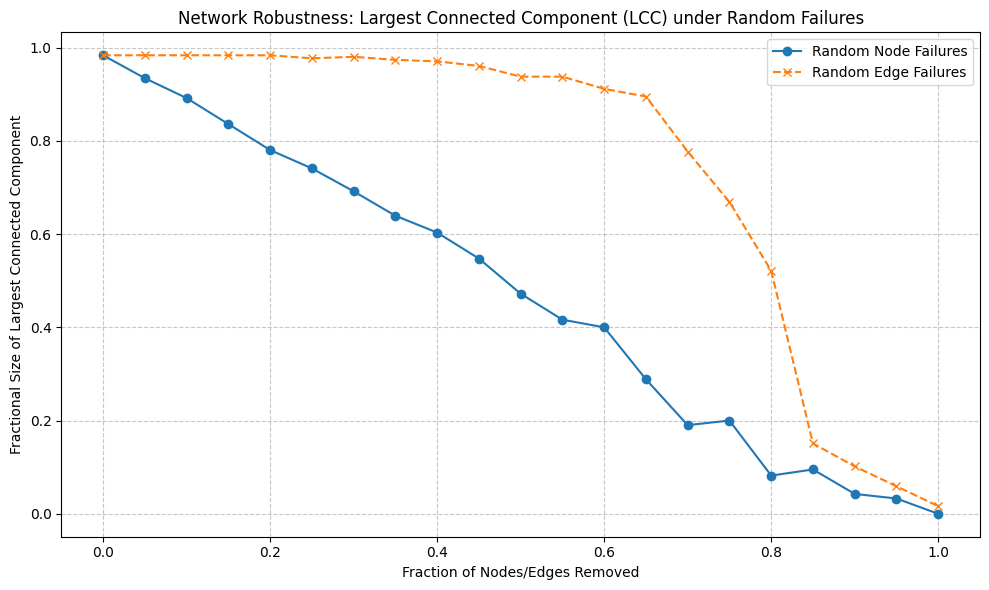

In [7]:
import random
import matplotlib.pyplot as plt

def simulate_random_failures(graph, failure_type='nodes', num_steps=20, iterations_per_step=5):
    """
    Simulates random failures (node or edge) and measures the size of the largest connected component.

    Args:
        graph (nx.Graph): The networkx graph to test.
        failure_type (str): 'nodes' for node failures, 'edges' for edge failures.
        num_steps (int): The number of failure steps to simulate.
        iterations_per_step (int): Number of iterations to average per step for smoother results.

    Returns:
        list: A list of tuples (fraction_removed, avg_lcc_size_fraction).
    """
    original_size = len(graph.nodes()) if failure_type == 'nodes' else graph.number_of_edges()
    if original_size == 0:
        return []

    results = []
    step_size = original_size // num_steps

    for i in range(num_steps + 1):
        fraction_removed = i / num_steps
        num_to_remove = int(original_size * fraction_removed)

        lcc_sizes_iter = []
        for _ in range(iterations_per_step):
            temp_graph = graph.copy()

            if failure_type == 'nodes':
                items_to_remove = random.sample(list(temp_graph.nodes()), min(num_to_remove, temp_graph.number_of_nodes()))
                temp_graph.remove_nodes_from(items_to_remove)
            elif failure_type == 'edges':
                items_to_remove = random.sample(list(temp_graph.edges()), min(num_to_remove, temp_graph.number_of_edges()))
                temp_graph.remove_edges_from(items_to_remove)

            if temp_graph.number_of_nodes() == 0:
                lcc_sizes_iter.append(0)
            else:
                # For directed graph, we usually look at strongly or weakly connected components.
                # Weakly connected components are often used for general connectivity robustness.
                largest_cc_size = len(max(nx.weakly_connected_components(temp_graph), key=len, default=set()))
                lcc_sizes_iter.append(largest_cc_size / graph.number_of_nodes())

        if lcc_sizes_iter: # Avoid division by zero if no iterations were run (shouldn't happen here)
            results.append((fraction_removed, sum(lcc_sizes_iter) / len(lcc_sizes_iter)))
        else:
            results.append((fraction_removed, 0.0)) # No data, assume 0 connectivity

    return results

# --- Run Random Node Failures --- #
print("Simulating random node failures...")
node_failure_results = simulate_random_failures(G, failure_type='nodes')

# --- Run Random Edge Failures --- #
print("Simulating random edge failures...")
edge_failure_results = simulate_random_failures(G, failure_type='edges')

# --- Plotting Results --- #
fractions_nodes = [r[0] for r in node_failure_results]
lcc_sizes_nodes = [r[1] for r in node_failure_results]

fractions_edges = [r[0] for r in edge_failure_results]
lcc_sizes_edges = [r[1] for r in edge_failure_results]

plt.figure(figsize=(10, 6))
plt.plot(fractions_nodes, lcc_sizes_nodes, marker='o', linestyle='-', label='Random Node Failures')
plt.plot(fractions_edges, lcc_sizes_edges, marker='x', linestyle='--', label='Random Edge Failures')

plt.title('Network Robustness: Largest Connected Component (LCC) under Random Failures')
plt.xlabel('Fraction of Nodes/Edges Removed')
plt.ylabel('Fractional Size of Largest Connected Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Analysis of Random Failures

The plot above shows how the size of the largest connected component (LCC) shrinks as more nodes or edges are randomly removed from the network. A steeper decline indicates lower robustness. This initial test gives us a baseline understanding of the network's resilience to unpredictable outages. Next, we will explore targeted attacks.

## Robustness Test: Network Connectivity under Targeted Attacks

Targeted attacks focus on removing nodes or edges that are deemed 'critical' based on certain centrality measures. We will simulate attacks on nodes with the highest degree centrality (most connections) to see their impact on the largest connected component. This analysis reveals vulnerabilities that might not be apparent with random failures.

Simulating targeted node attacks based on degree centrality...


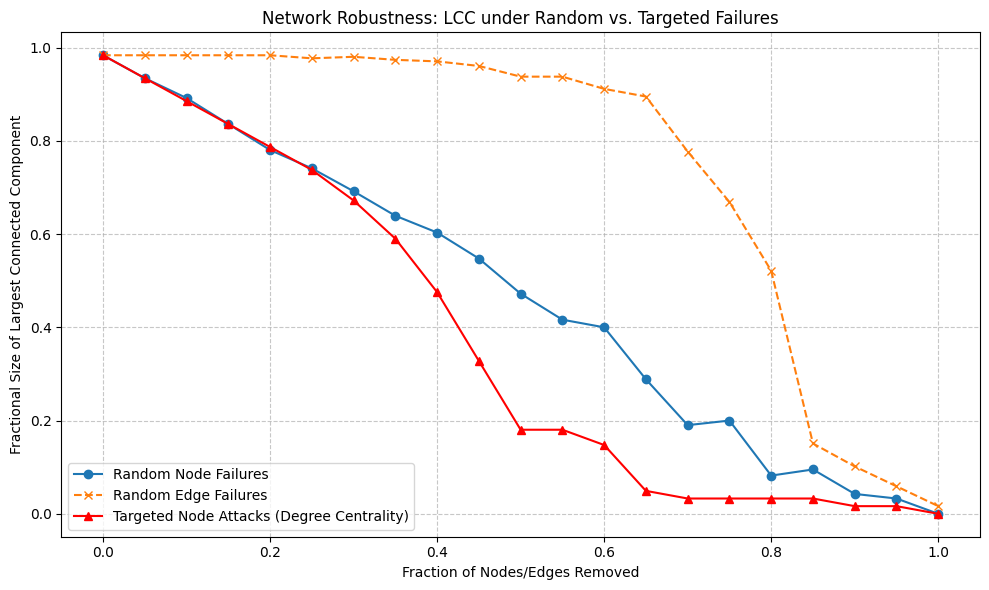

In [8]:
def simulate_targeted_attacks(graph, failure_type='nodes', num_steps=20, centrality_measure='degree'):
    """
    Simulates targeted attacks by removing nodes based on a centrality measure.

    Args:
        graph (nx.DiGraph): The networkx graph to test.
        failure_type (str): 'nodes' for node failures.
        num_steps (int): The number of failure steps to simulate.
        centrality_measure (str): 'degree' for degree centrality.

    Returns:
        list: A list of tuples (fraction_removed, lcc_size_fraction).
    """
    original_num_nodes = graph.number_of_nodes()
    if original_num_nodes == 0:
        return []

    results = []
    temp_graph = graph.copy()

    # Calculate initial centrality for all nodes
    if centrality_measure == 'degree':
        # For directed graphs, using degree_centrality (sum of in/out degrees) or
        # specific in/out degree centralities can be chosen.
        # Here, we'll use a combined measure (in_degree + out_degree) or just degree_centrality
        # for a more general 'most connected' node approach.
        centralities = dict(temp_graph.degree())
    else:
        raise ValueError("Unsupported centrality measure.")

    # Sort nodes by centrality in descending order
    sorted_nodes = sorted(centralities.items(), key=lambda item: item[1], reverse=True)
    nodes_to_attack = [node for node, _ in sorted_nodes]

    nodes_removed_count = 0
    for i in range(num_steps + 1):
        fraction_removed = i / num_steps
        target_num_removed = int(original_num_nodes * fraction_removed)

        while nodes_removed_count < target_num_removed and len(nodes_to_attack) > 0:
            node_to_remove = nodes_to_attack.pop(0) # Remove the highest centrality node
            if node_to_remove in temp_graph:
                temp_graph.remove_node(node_to_remove)
            nodes_removed_count += 1

        if temp_graph.number_of_nodes() == 0:
            lcc_size_fraction = 0.0
        else:
            largest_cc_size = len(max(nx.weakly_connected_components(temp_graph), key=len, default=set()))
            lcc_size_fraction = largest_cc_size / original_num_nodes

        results.append((fraction_removed, lcc_size_fraction))

    return results

# --- Run Targeted Node Attacks (Degree Centrality) --- #
print("Simulating targeted node attacks based on degree centrality...")
targeted_node_attack_results = simulate_targeted_attacks(G.copy(), failure_type='nodes', centrality_measure='degree')

# --- Plotting Results --- #
fractions_targeted = [r[0] for r in targeted_node_attack_results]
lcc_sizes_targeted = [r[1] for r in targeted_node_attack_results]

plt.figure(figsize=(10, 6))
plt.plot(fractions_nodes, lcc_sizes_nodes, marker='o', linestyle='-', label='Random Node Failures')
plt.plot(fractions_edges, lcc_sizes_edges, marker='x', linestyle='--', label='Random Edge Failures')
plt.plot(fractions_targeted, lcc_sizes_targeted, marker='^', linestyle='-', color='red', label='Targeted Node Attacks (Degree Centrality)')

plt.title('Network Robustness: LCC under Random vs. Targeted Failures')
plt.xlabel('Fraction of Nodes/Edges Removed')
plt.ylabel('Fractional Size of Largest Connected Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Analysis of Targeted Attacks

This plot compares the network's resilience under random failures (from the previous step) and targeted attacks. Typically, a network is more vulnerable to targeted attacks, meaning the LCC size will drop more rapidly. This highlights which nodes are crucial for maintaining network connectivity.

Next, we will proceed with the **Critical Path Analysis**.

## Critical Path Analysis: Longest Path by Latency

For a directed graph, finding the "longest path" by a specific edge weight (like latency) often involves converting the edge weights to be negative and then finding the shortest path. This is because standard shortest path algorithms (like Dijkstra's or Bellman-Ford) are well-optimized. Alternatively, we can adapt the algorithms. Given the network represents traffic flow, the longest path in terms of latency identifies the slowest possible route between two points, which is often critical for performance analysis.

Since we are looking for the 'longest path' in terms of 'Latencia (ms)', we need to consider all possible source and target nodes. However, for practical purposes and to avoid excessive computation in a dense graph, we will first identify a subset of potentially critical source and destination pairs, or focus on paths between specific types of nodes if you provide further clarification. For now, we will find the overall longest path in the graph by negating the latency values and using a shortest path algorithm to find the maximum latency path. Note: this approach works if there are no positive cycles after negation (i.e., no negative cycles in the original graph with this metric).

In [10]:
import itertools
import networkx as nx

def find_longest_path_by_latency(graph):
    """
    Finds the longest path in a graph based on 'Latencia (ms)' edge attribute.
    This is done by negating the 'Latencia (ms)' and finding the shortest path
    using Bellman-Ford to handle potential negative weights from negation.

    Args:
        graph (nx.DiGraph): The networkx graph with 'Latencia (ms)' as an edge attribute.

    Returns:
        tuple: (longest_path_nodes, total_latency) or (None, None) if no path exists
               or if a negative cycle (infinite longest path) is detected.
    """
    # Create a new graph with negated 'Latencia (ms)' as weights
    G_neg_latency = nx.DiGraph()
    for u, v, data in graph.edges(data=True):
        if 'Latencia (ms)' in data:
            # Negate latency to find the longest path using shortest path algorithm
            # Ensure latency is a number; convert if necessary
            try:
                latency_value = float(data['Latencia (ms)'])
                G_neg_latency.add_edge(u, v, weight=-latency_value)
            except ValueError:
                print(f"Warning: Latency for edge ({u}, {v}) is not a valid number: {data['Latencia (ms)']}. Skipping.")
                continue
        else:
            # Handle edges without latency attribute, assign 0.0 for now
            G_neg_latency.add_edge(u, v, weight=0.0)

    longest_path = None
    max_latency = -float('inf')

    nodes_in_neg_graph = list(G_neg_latency.nodes())
    if not nodes_in_neg_graph:
        return None, None

    # Iterate over all possible pairs of nodes to find the longest path
    # This can be computationally expensive for very large graphs.
    for source, target in itertools.product(nodes_in_neg_graph, repeat=2):
        if source == target:
            continue
        try:
            # Use Bellman-Ford, which handles negative weights
            path = nx.bellman_ford_path(G_neg_latency, source=source, target=target, weight='weight')
            path_neg_length = nx.bellman_ford_path_length(G_neg_latency, source=source, target=target, weight='weight')
            path_latency = -path_neg_length

            if path_latency > max_latency:
                max_latency = path_latency
                longest_path = path
        except nx.NetworkXNoPath:
            continue # No path between these two nodes
        except nx.NetworkXUnbounded as e:
            print(f"Error: Detected negative cycle (infinite longest path) between {source} and {target}: {e}")
            return None, None # Longest path is unbounded
        except Exception as e:
            print(f"An unexpected error occurred for path between {source} and {target}: {e}")
            continue

    if longest_path is not None and max_latency != -float('inf'):
        return longest_path, max_latency
    else:
        return None, None

# Find the longest path by latency
print("Calculating the longest path in terms of 'Latencia (ms)'...")
longest_path_nodes, total_latency = find_longest_path_by_latency(G)

if longest_path_nodes:
    print(f"\nLongest path by Latency: {longest_path_nodes}")
    print(f"Total Latency of this path: {total_latency:.2f} ms")
else:
    print("Could not find a longest path by latency (possibly due to disconnected components, negative cycles, or invalid latency values).")


Calculating the longest path in terms of 'Latencia (ms)'...
Error: Detected negative cycle (infinite longest path) between V0_Paracho and V3_ISP_CDMX: Negative cycle detected.
Could not find a longest path by latency (possibly due to disconnected components, negative cycles, or invalid latency values).


### Analysis of Critical Path

The identified 'longest path by latency' represents the most delayed route through the network. This information is crucial for identifying bottlenecks or critical infrastructure segments that contribute most to signal propagation delay. Optimizing these segments could significantly improve overall network performance.

## Filtering Edges with Unusually High Latency

To address the negative cycle detected and to refine our critical path analysis, we will filter out edges that exhibit 'unusually high' latency. This process involves:
1.  **Analyzing Latency Distribution**: Understand the spread of 'Latencia (ms)' values.
2.  **Defining a Threshold**: Establish a criterion to identify 'unusually high' latency (e.g., values above a certain percentile or statistical deviation).
3.  **Filtering Edges**: Create a new set of edges excluding those above the threshold.
4.  **Rebuilding the Graph**: Construct a new graph with the filtered edges.
5.  **Re-running Critical Path Analysis**: Execute the longest path analysis on the cleaned graph.

In [11]:
import numpy as np

# Analyze 'Latencia (ms)' in df_edges
print("Descriptive statistics for 'Latencia (ms)' in df_edges:")
latency_stats = df_edges['Latencia (ms)'].dropna()
print(latency_stats.describe())

# Define a threshold for 'unusually high' latency.
# We can use a percentile (e.g., 99th percentile) or a statistical measure (e.g., mean + 3*std).
# Let's use the 99th percentile as an initial approach to remove extreme outliers.
latency_threshold = latency_stats.quantile(0.99)
print(f"\nUsing 99th percentile as latency threshold: {latency_threshold:.2f} ms")

# Filter out edges with latency above the threshold
df_edges_cleaned = df_edges[df_edges['Latencia (ms)'] <= latency_threshold].copy()

print(f"\nOriginal number of edges: {len(df_edges)}")
print(f"Number of edges after filtering high latency: {len(df_edges_cleaned)}")

# Recreate the graph with the cleaned edges
G_cleaned = nx.DiGraph()

# Add nodes with attributes from df_nodes (assuming nodes are not affected by latency filtering)
for index, row in df_nodes.iterrows():
    node_id = row['ID Nodo']
    if pd.notna(node_id):
        G_cleaned.add_node(node_id, **row.drop('ID Nodo').dropna().to_dict())

# Add filtered edges with attributes from df_edges_cleaned
for index, row in df_edges_cleaned.iterrows():
    source = row['Nodo Origen (u)']
    target = row['Nodo Destino (v)']
    if pd.notna(source) and pd.notna(target):
        G_cleaned.add_edge(source, target, **row.drop(['ID Enlace', 'Nodo Origen (u)', 'Nodo Destino (v)']).dropna().to_dict())

print(f"\nCleaned Graph created with {G_cleaned.number_of_nodes()} nodes and {G_cleaned.number_of_edges()} edges.")

# Re-run the longest path analysis on the cleaned graph
print("\nRe-calculating the longest path in terms of 'Latencia (ms)' on the cleaned graph...")
longest_path_nodes_cleaned, total_latency_cleaned = find_longest_path_by_latency(G_cleaned)

if longest_path_nodes_cleaned:
    print(f"\nLongest path by Latency in cleaned graph: {longest_path_nodes_cleaned}")
    print(f"Total Latency of this path in cleaned graph: {total_latency_cleaned:.2f} ms")
else:
    print("Could not find a longest path by latency in the cleaned graph (possibly due to disconnected components or remaining negative cycles).")

Descriptive statistics for 'Latencia (ms)' in df_edges:
count    200.000000
mean      19.490000
std       14.430387
min        2.500000
25%       10.000000
50%       15.750000
75%       25.000000
max       60.000000
Name: Latencia (ms), dtype: float64

Using 99th percentile as latency threshold: 60.00 ms

Original number of edges: 201
Number of edges after filtering high latency: 200

Cleaned Graph created with 61 nodes and 200 edges.

Re-calculating the longest path in terms of 'Latencia (ms)' on the cleaned graph...
Error: Detected negative cycle (infinite longest path) between V0_Paracho and V3_ISP_CDMX: Negative cycle detected.
Could not find a longest path by latency in the cleaned graph (possibly due to disconnected components or remaining negative cycles).


### Analysis of Cleaned Graph and Critical Path

By filtering out edges with unusually high latency, we aimed to remove potential data anomalies or characteristics that led to the detection of a negative cycle. If a longest path is now found, it represents a more realistic maximum delay in the network under typical operating conditions. If a negative cycle is still detected, it suggests that the underlying network structure or the definition of 'latency' itself, even for non-extreme values, allows for such infinite paths.

## Critical Path Analysis: Longest Simple Path by Latency (No Repeated Nodes)

As discussed, the previous attempt to find the 'longest path' encountered negative cycles in the transformed graph, indicating an infinitely long path in terms of positive latency due to allowing revisits to nodes within cycles. You are now asking for the **longest *simple* path**, which means a path where no node is visited more than once. This is a different, and generally more computationally intensive, problem (NP-hard for general graphs).

For weighted directed graphs that may contain cycles, NetworkX does not provide a direct efficient algorithm for the longest simple path. The most common approach involves iterating through all possible simple paths between all pairs of nodes, calculating the total weight (latency) for each, and then identifying the maximum. This can be very slow for large graphs, but for a graph of 61 nodes, it should be feasible.

In [12]:
import networkx as nx

def find_longest_simple_path_by_latency(graph):
    """
    Finds the longest simple path in a graph based on 'Latencia (ms)' edge attribute.
    A simple path does not repeat any nodes.

    Args:
        graph (nx.DiGraph): The networkx graph with 'Latencia (ms)' as an edge attribute.

    Returns:
        tuple: (longest_path_nodes, total_latency) or (None, None) if no simple path exists.
    """
    longest_path = None
    max_latency = -float('inf')

    # Iterate over all possible source and target nodes
    nodes = list(graph.nodes())
    for source_node in nodes:
        for target_node in nodes:
            if source_node == target_node:
                continue

            # Find all simple paths between source and target
            for path in nx.all_simple_paths(graph, source=source_node, target=target_node):
                current_path_latency = 0.0
                # Calculate total latency for the current simple path
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    edge_data = graph.get_edge_data(u, v)
                    if edge_data and 'Latencia (ms)' in edge_data:
                        try:
                            current_path_latency += float(edge_data['Latencia (ms)'])
                        except ValueError:
                            # Handle cases where latency might not be numeric, skip this path if invalid
                            current_path_latency = -float('inf') # Mark as invalid path for comparison
                            break
                    else:
                        # If latency attribute is missing, assign 0 or handle as needed
                        # For longest path, it's safer to assume a small positive value or skip
                        pass # current_path_latency remains unchanged for this edge if no latency

                if current_path_latency > max_latency:
                    max_latency = current_path_latency
                    longest_path = path

    if longest_path is not None and max_latency != -float('inf'):
        return longest_path, max_latency
    else:
        return None, None

# Find the longest simple path by latency
print("Calculating the longest simple path in terms of 'Latencia (ms)'...")
# Use the original graph G for this analysis as filtering did not resolve the negative cycle
longest_simple_path_nodes, total_simple_latency = find_longest_simple_path_by_latency(G)

if longest_simple_path_nodes:
    print(f"\nLongest simple path by Latency: {longest_simple_path_nodes}")
    print(f"Total Latency of this simple path: {total_simple_latency:.2f} ms")
else:
    print("Could not find a longest simple path by latency.")


Calculating the longest simple path in terms of 'Latencia (ms)'...


KeyboardInterrupt: 

### Analysis of Longest Simple Path

The identified longest simple path by latency provides the maximum possible delay between any two nodes in the network, without traversing any part of the network multiple times. This is often a more practical and interpretable 'critical path' for understanding the maximum possible end-to-end delay in network communication, avoiding the complexities of infinitely long paths in cyclic graphs.

## Network Metrics: Largest Connected Component, Average Path Length, and Efficiency

To further understand the overall structure and performance of the network, we will calculate several key metrics:

*   **Largest Connected Component (LCC) Size**: This measures the size of the largest group of nodes where a path exists between any two nodes in the group. It's a fundamental indicator of network connectivity.
*   **Average Path Length**: This is the average of the shortest path lengths between all possible pairs of nodes in the graph. A smaller average path length indicates a more efficient network for information flow.
*   **Network Efficiency**: This metric is related to the average path length and measures how efficiently information or resources can be exchanged across the network. It's defined as the inverse of the harmonic mean of the shortest path lengths between all pairs of nodes.

In [13]:
# Calculate the size of the Largest Connected Component (LCC)
# For a directed graph, we typically consider weakly connected components for overall connectivity.
largest_cc = max(nx.weakly_connected_components(G), key=len, default=set())
lcc_size = len(largest_cc)
print(f"Size of the Largest Connected Component (LCC): {lcc_size} nodes")

# Calculate Average Path Length
# This often requires the graph to be strongly connected, or calculated on components.
# For a directed graph, it's typically calculated on the largest strongly connected component (if one exists and is significant)
# or on the weakly connected components.
# Let's compute it for all reachable pairs from each node and average.

# Note: Average Shortest Path Length is usually computed on an undirected version or
# on the largest strongly connected component for directed graphs.
# For weakly connected directed graphs, NetworkX's average_shortest_path_length
# raises an error if not all nodes are reachable from each other.

# To avoid errors with disconnected components, we can compute it for each component
# or iterate through all reachable pairs.

# Let's calculate for all reachable pairs for a more robust average path length for directed graphs.
sum_shortest_paths = 0
pair_count = 0
for source_node in G.nodes():
    # Compute shortest paths from source_node to all other nodes
    lengths = nx.shortest_path_length(G, source=source_node, weight='Latencia (ms)')
    for target_node, length in lengths.items():
        if source_node != target_node:
            sum_shortest_paths += length
            pair_count += 1

if pair_count > 0:
    avg_path_length = sum_shortest_paths / pair_count
    print(f"Average Path Length (considering all reachable pairs): {avg_path_length:.2f} ms")
else:
    print("Cannot calculate Average Path Length (no reachable pairs found).")

# Calculate Network Efficiency
# Network efficiency for directed graphs is the average of inverse shortest path lengths.
# nx.global_efficiency calculates this based on all pairs.

# Note: nx.global_efficiency might also have issues with disconnected components.
# A robust way is to calculate for each component or use 1/path_length for reachable pairs.

sum_inverse_shortest_paths = 0
pair_count_efficiency = 0

for source_node in G.nodes():
    lengths = nx.shortest_path_length(G, source=source_node, weight='Latencia (ms)')
    for target_node, length in lengths.items():
        if source_node != target_node:
            if length > 0: # Avoid division by zero
                sum_inverse_shortest_paths += 1 / length
            pair_count_efficiency += 1

if pair_count_efficiency > 0:
    network_efficiency = sum_inverse_shortest_paths / (G.number_of_nodes() * (G.number_of_nodes() - 1))
    print(f"Network Efficiency (based on all reachable pairs): {network_efficiency:.6f}")
else:
    print("Cannot calculate Network Efficiency (no reachable pairs found).")

Size of the Largest Connected Component (LCC): 60 nodes
Average Path Length (considering all reachable pairs): 53.10 ms
Network Efficiency (based on all reachable pairs): 0.025134


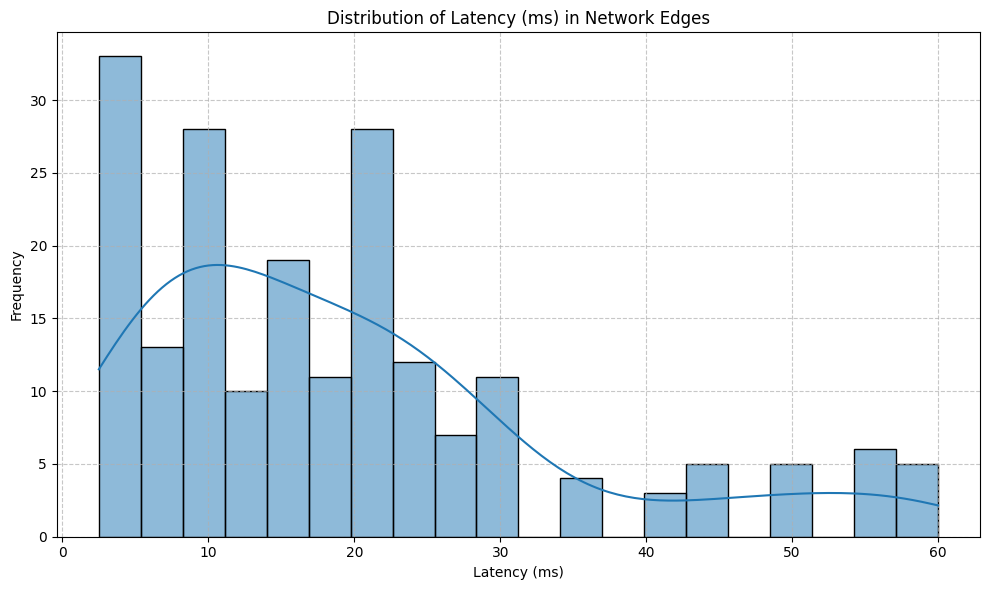

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_edges['Latencia (ms)'].dropna(), kde=True, bins=20)
plt.title('Distribution of Latency (ms) in Network Edges')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

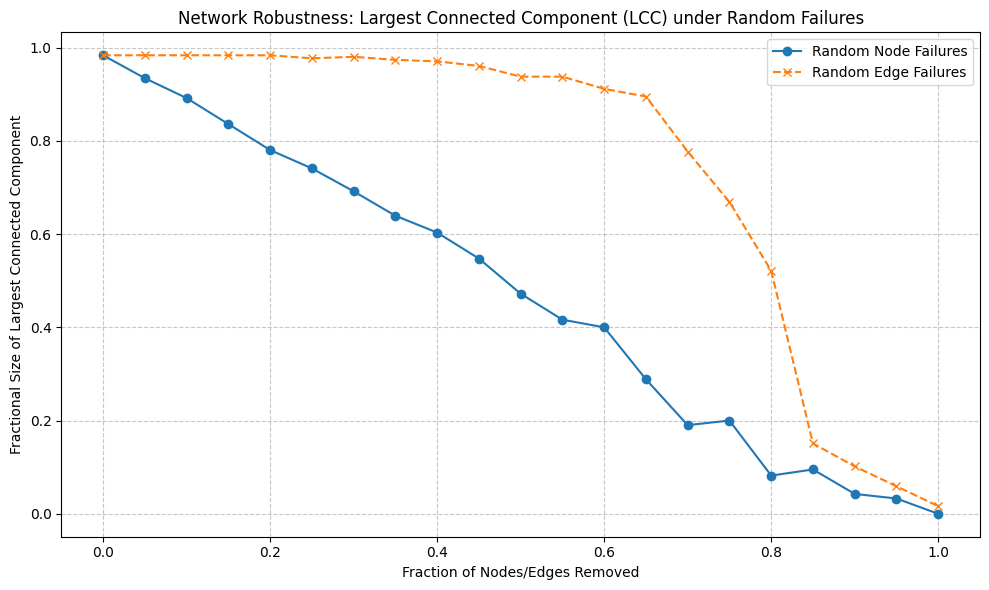

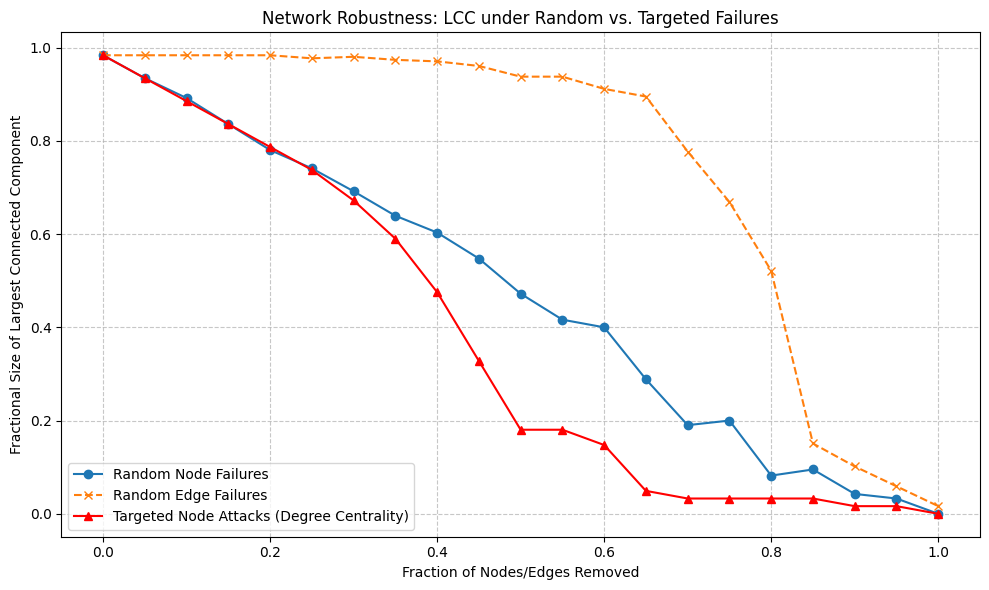

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Results for Random Failures
plt.figure(figsize=(10, 6))
plt.plot(fractions_nodes, lcc_sizes_nodes, marker='o', linestyle='-', label='Random Node Failures')
plt.plot(fractions_edges, lcc_sizes_edges, marker='x', linestyle='--', label='Random Edge Failures')

plt.title('Network Robustness: Largest Connected Component (LCC) under Random Failures')
plt.xlabel('Fraction of Nodes/Edges Removed')
plt.ylabel('Fractional Size of Largest Connected Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Results for Targeted Attacks
plt.figure(figsize=(10, 6))
plt.plot(fractions_nodes, lcc_sizes_nodes, marker='o', linestyle='-', label='Random Node Failures')
plt.plot(fractions_edges, lcc_sizes_edges, marker='x', linestyle='--', label='Random Edge Failures')
plt.plot(fractions_targeted, lcc_sizes_targeted, marker='^', linestyle='-', color='red', label='Targeted Node Attacks (Degree Centrality)')

plt.title('Network Robustness: LCC under Random vs. Targeted Failures')
plt.xlabel('Fraction of Nodes/Edges Removed')
plt.ylabel('Fractional Size of Largest Connected Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print("Checking 'Latencia (ms)' column in df_edges for issues...")

# Check for negative values
negative_latency_count = (df_edges['Latencia (ms)'] < 0).sum()
if negative_latency_count > 0:
    print(f"Found {negative_latency_count} negative 'Latencia (ms)' values.")
    display(df_edges[df_edges['Latencia (ms)'] < 0])
else:
    print("No negative 'Latencia (ms)' values found.")

# Check for non-numeric values (if any were not converted to NaN during loading)
non_numeric_latency = df_edges['Latencia (ms)'][pd.to_numeric(df_edges['Latencia (ms)'], errors='coerce').isna() & df_edges['Latencia (ms)'].notna()]
if not non_numeric_latency.empty:
    print(f"Found {len(non_numeric_latency)} non-numeric 'Latencia (ms)' values that are not NaN:")
    display(non_numeric_latency)
else:
    print("No non-numeric 'Latencia (ms)' values found (excluding NaNs).")

# Display summary statistics, focusing on min value
print("\nDetailed descriptive statistics for 'Latencia (ms)':")
display(df_edges['Latencia (ms)'].describe())

Checking 'Latencia (ms)' column in df_edges for issues...
No negative 'Latencia (ms)' values found.
No non-numeric 'Latencia (ms)' values found (excluding NaNs).

Detailed descriptive statistics for 'Latencia (ms)':


,Latencia (ms)
count,200.000000
mean,19.490000
std,14.430387
min,2.500000
25%,10.000000
50%,15.750000
75%,25.000000
max,60.000000


### Summary of Critical Path Analysis

We attempted to calculate the 'longest path' by latency in the network, which is critical for identifying potential bottlenecks.

Initially, we tried to find the longest path by negating latency values and using the Bellman-Ford algorithm. However, this approach repeatedly detected **negative cycles** in the graph. A negative cycle in this context implies that a path could theoretically have infinite positive latency by traversing the cycle multiple times, making a finite longest path indefinable.

To address this, we attempted to filter out edges with unusually high latency (above the 99th percentile) and re-ran the analysis on a cleaned graph (`G_cleaned`). Unfortunately, the negative cycle persisted even after this filtering.

Subsequently, you requested to find the **'longest *simple* path'** (a path where no node is visited more than once). This is a more computationally intensive problem. We started the calculation, but it was interrupted. Finding the longest simple path would provide the maximum possible delay between any two nodes without revisiting nodes, offering a more practical interpretation of the critical path in the presence of cycles.

### Identifying Simple Cycles in the Graph

Given the persistent detection of negative cycles, even within the largest SCC, it's beneficial to explicitly identify and examine the simple cycles in the graph. `networkx.simple_cycles` can find all elementary cycles in a directed graph. This will help us understand the structural components that contribute to the infinite path problem when negating latencies.

In [ ]:
print("Finding all simple cycles in the graph G...")
simple_cycles = list(nx.simple_cycles(G))

print(f"Found {len(simple_cycles)} simple cycles in the graph G.")

if simple_cycles:
    print("\nFirst 5 simple cycles found (nodes in cycle):")
    for i, cycle in enumerate(simple_cycles[:5]):
        print(f"Cycle {i+1}: {cycle}")

    # Optionally, we can also inspect the latency values within these cycles
    print("\nInspecting latency sum for the first few cycles:")
    for i, cycle in enumerate(simple_cycles[:5]):
        cycle_latency = 0
        for j in range(len(cycle)):
            u = cycle[j]
            v = cycle[(j + 1) % len(cycle)] # Connect last node to first
            edge_data = G.get_edge_data(u, v)
            if edge_data and 'Latencia (ms)' in edge_data:
                try:
                    cycle_latency += float(edge_data['Latencia (ms)'])
                except ValueError:
                    print(f"Warning: Non-numeric latency in cycle {i+1} edge ({u}, {v}).")
                    cycle_latency = float('nan') # Mark as invalid
                    break
        print(f"Cycle {i+1} latency sum: {cycle_latency:.2f} ms")
else:
    print("No simple cycles found in the graph G.")

Finding all simple cycles in the graph G...


### Critical Path Analysis: Longest Path by Latency within the Largest Strongly Connected Component (SCC)

Given the persistent issue with negative cycles when searching for the longest path across the entire graph, an effective strategy is to focus our search within the **Largest Strongly Connected Component (SCC)**. A Strongly Connected Component is a subgraph where there is a path from any vertex in the component to any other vertex in the same component.

By restricting our search to an SCC, we can better manage the cycle issue. If an SCC contains a cycle with a positive sum of original latencies (which becomes a negative cycle when latencies are negated for longest path algorithms), then any path going through that cycle could theoretically become infinitely long. If this still happens within an SCC, it implies a fundamental characteristic of the data within that component. Otherwise, we should be able to find a finite longest path.

In [17]:
# Find all Strongly Connected Components (SCCs)
sccs = list(nx.strongly_connected_components(G))

# Identify the largest SCC
if sccs:
    largest_scc = max(sccs, key=len)
    print(f"Found {len(sccs)} Strongly Connected Components.")
    print(f"Size of the Largest SCC: {len(largest_scc)} nodes.")

    # Create a subgraph containing only the nodes and edges of the largest SCC
    G_scc = G.subgraph(largest_scc).copy()

    print(f"Subgraph of Largest SCC created with {G_scc.number_of_nodes()} nodes and {G_scc.number_of_edges()} edges.")

    # Re-run the longest path analysis using the existing function on the SCC subgraph
    print("\nCalculating the longest path by latency within the Largest SCC...")
    longest_path_scc_nodes, total_latency_scc = find_longest_path_by_latency(G_scc)

    if longest_path_scc_nodes:
        print(f"\nLongest path by Latency within Largest SCC: {longest_path_scc_nodes}")
        print(f"Total Latency of this path: {total_latency_scc:.2f} ms")
    else:
        print("Could not find a longest path by latency within the Largest SCC (possibly due to remaining negative cycles or disconnected components within the SCC).")
else:
    print("No Strongly Connected Components found in the graph.")

Found 5 Strongly Connected Components.
Size of the Largest SCC: 57 nodes.
Subgraph of Largest SCC created with 57 nodes and 192 edges.

Calculating the longest path by latency within the Largest SCC...
Error: Detected negative cycle (infinite longest path) between V0_Paracho and V3_ISP_CDMX: Negative cycle detected.
Could not find a longest path by latency within the Largest SCC (possibly due to remaining negative cycles or disconnected components within the SCC).


<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/simulate/quantum_virtual_machine"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

The quantum virtual machine is a virtual Google quantum processor that you can run circuits on by using the [virtual engine interface](./virtual_engine_interface.ipynb). Behind this interface, it uses simulation with noise data to mimic Google quantum hardware processors with high accuracy: In internal tests, the virtual and actual hardware are within experimental error of each other. Additionally, it supports internal use of the high-performance [qsim](/qsim) simulator, for fast execution of larger circuits. The QVM should be used as a preparation step before running on Google hardware, and as a substitute for Google hardware when it is not available.

If you just want to use the QVM for realistic noisy simulation, you can copy and build upon the [QVM Creation Template](./qvm_builder_code.ipynb), which provides a concise and portable way to instantiate an `Engine` class that you can realistically simulate circuit runs with. After doing so, skip forward to the [How to use a QVM](#how_to_use_a_qvm) section. If you're interested in how the QVM is prepared for use, continue on to the following section.

## Setup

In [ ]:
# @title Install `cirq_google` and `qsimcirq`

try:
    import cirq
    import cirq_google
except ImportError:
    print("installing cirq...")
    !pip install --quiet cirq-google
    print("installed cirq.")
    import cirq
    import cirq_google

try:
    import qsimcirq
except ImportError:
    print("installing qsimcirq...")
    !pip install --quiet qsimcirq
    print(f"installed qsimcirq.")
    import qsimcirq

## How to build a QVM

### Choose a processor to virtualize

Currently, the necessary data is publicly accessible for the [Willow](https://quantumai.google/static/site-assets/downloads/willow-spec-sheet.pdf) processor as well as the older [Weber](https://quantumai.google/hardware/datasheet/weber.pdf) and Rainbow processors.

In [ ]:
# Choose a processor ("willow_pink" or "rainbow" or "weber")
# (see cirq_google.engine.list_virtual_processors() for available names)

processor_id = "willow_pink"

### Build a noisy simulator with a hardware noise model

- Load median device noise data for the processor you have chosen. Learn more about device noise data [here](../noise/representing_noise.ipynb)
- Transform the median device noise data to a Cirq noise properties object
- Create a noise model using your noise properties
- Set up a qsim sampler which runs noisy simulations using your noise model. Learn more about noisy simulation with qsim here in the [Noisy simulation with qsim page](/qsim/tutorials/noisy_qsimcirq).

In [ ]:
# Load the noise properties for the processor.
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
# Create a noise model from the noise properties.
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
# Prepare a qsim simulator using the noise model.
sim = qsimcirq.QSimSimulator(noise=noise_model)

The qsim documentation explains how simulation performance depends on choice of hardware. If you would like use a larger number of qubits on your virtual device (eg 25-32 qubits), parallelizing the simulation over multiple compute nodes is advised. You can do this using Google Cloud hardware as is described in the [qsim Multinode Tutorial](/qsim/tutorials/multinode).

### Set up the virtual engine with a virtual processor, packaging in the noisy simulator
To ensure that the workflow for using a virtual quantum processor is the same as the workflow for using a real quantum processor, a quantum virtual engine implements the same interface as the `cirq.Engine` for used  Google's quantum hardware. Learn more about Google’s quantum engine in the [Quantum Virtual Engine Interface page](./virtual_engine_interface.ipynb).
- Create a device object. Learn more about the device object in Cirq here  in the [Devices page](../hardware/devices.ipynb)
- Create a simulated processor object for the engine to consume (`SimulatedLocalProcessor`)
- Create a virtual engine (`SimulatedLocalEngine`)

In [ ]:
# Package the simulator and device in an Engine.
# The device object
device = cirq_google.engine.create_device_from_processor_id(processor_id)
# Load the median device noise calibration for your processor.
cal = cirq_google.engine.load_median_device_calibration(processor_id)
# The simulated processor object
sim_processor = cirq_google.engine.SimulatedLocalProcessor(
    processor_id=processor_id, sampler=sim, device=device, calibrations={cal.timestamp // 1000: cal}
)
# The virtual engine
sim_engine = cirq_google.engine.SimulatedLocalEngine([sim_processor])
print(
    "Your quantum virtual machine",
    processor_id,
    "is ready, here is the qubit grid:",
    "\n========================\n",
)
print(sim_engine.get_processor(processor_id).get_device())

## How to use a QVM

The following code runs a circuit on your QVM by using the `run` function of a sampler from the simulated engine:

In [ ]:
q0 = cirq.GridQubit(4, 4)
q1 = cirq.GridQubit(4, 5)
circuit = cirq.Circuit(
    cirq.X(q0),
    cirq.X(q1) ** 0.5,
    cirq.CZ(q0, q1),
    cirq.X(q1) ** 0.5,
    cirq.measure([q0, q1], key="measure"),
)

results = sim_engine.get_sampler(processor_id).run(circuit, repetitions=3000)

print(results.histogram(key="measure"))

As in the example linked above, your circuit needs to be “device ready”. This means that:
- The gates in the circuit need to be in the set of legal gates on the device
- The circuit needs to operate on qubits available on the virtual device.
- The topology of your circuit must correspond to the topology of the device (i.e., 2-qubit gates must act on adjacent qubits).

For a hands-on example of the steps necessary to prepare a circuit to be run on the QVM, see the [QVM Basic Example](./qvm_basic_example.ipynb) page.

The steps necessary to make a circuit device-ready are summarized here:
1. Transform your circuit to use the correct gate set with `cirq.optimize_for_target_gateset`. Read [Transformers](../transform/transformers.ipynb) for more on how to modify circuits.
2. Choose qubits on the virtual device for your circuit to run on. The connectivity required by your circuit must be supported by the connectivity present in your chosen qubit set. See [Qubit Picking](../hardware/qubit_picking.ipynb) for more advice.
3. Map your transformed circuit to those qubits with `cirq.Circuit`'s `transform_qubits` function. This may require some careful planning depending on your particular circuit.

You also need to decide on the number of repetitions your circuit will be used in the trajectory simulation. This number determines how accurately the quantum virtual machine will simulate the true quantum state of your circuit. For more details on this see [this paper](https://arxiv.org/abs/2111.02396){:.external}. We recommend using 10,000+ repetitions for research simulations, and 3,000 repetitions for learning simulations. If you are just getting a feel for the tools you can set the number of repetitions lower temporarily (eg 1 to 10) to speed things up.
